In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Load dataset
df = pd.read_csv('insurance.csv')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Encode categorical variables for OLS
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


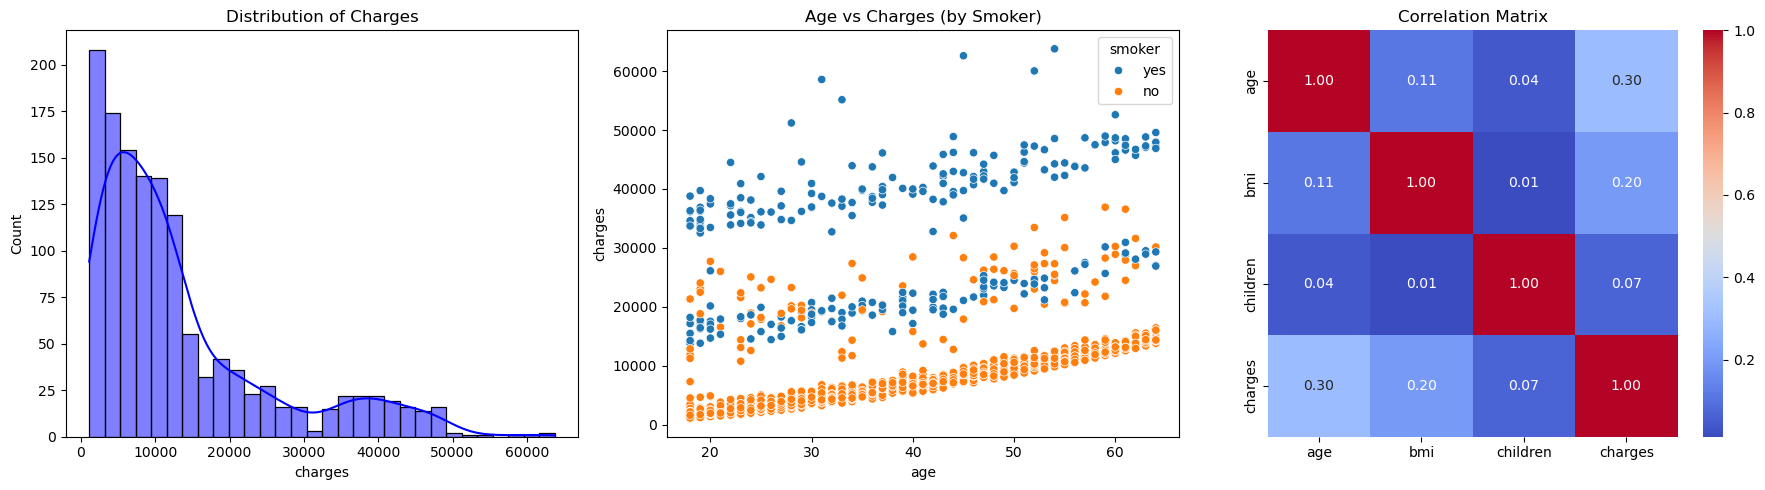

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of Charges (Histogram & KDE)
sns.histplot(df['charges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Charges')

# 2. Age vs Charges (Separated by Smoker Status)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[1])
axes[1].set_title('Age vs Charges (by Smoker)')

# 3. Correlation Matrix
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [7]:
# Define Features (X) and Target (Y)
X = df_encoded.drop('charges', axis=1)
X = sm.add_constant(X) # Add y-intercept
Y = df_encoded['charges']

# Fit OLS Model
model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:10:53   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

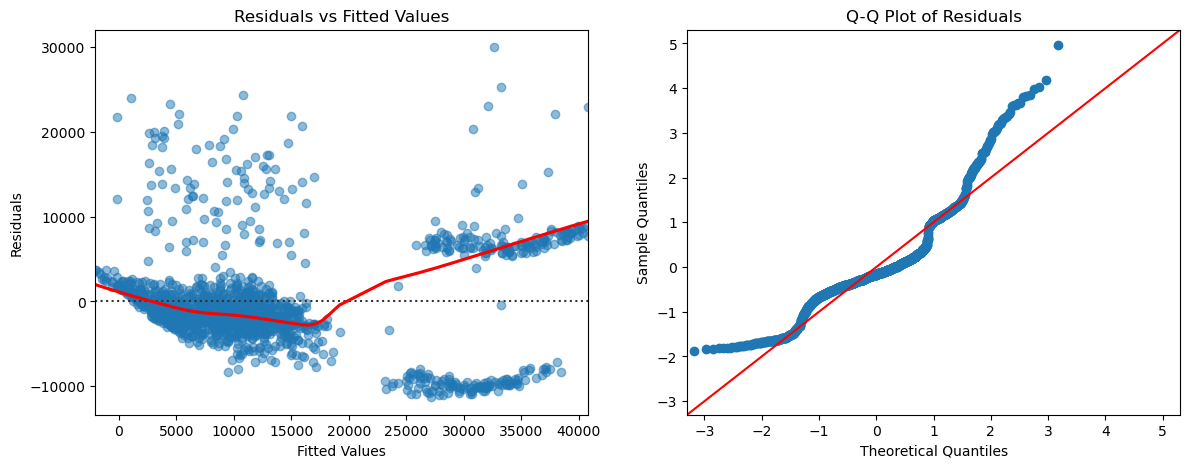


Variance Inflation Factors (VIF):
            Feature       VIF
1               age  1.016822
2               bmi  1.106630
3          children  1.004011
4          sex_male  1.008900
5        smoker_yes  1.012074
6  region_northwest  1.518823
7  region_southeast  1.652230
8  region_southwest  1.529411


In [8]:
residuals = model.resid
fitted_values = model.fittedvalues

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Linearity & Homoscedasticity (Residuals vs Fitted)
sns.residplot(x=fitted_values, y=residuals, lowess=True, 
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[0])
ax[0].set_title('Residuals vs Fitted Values')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')

# 2. Normality of Residuals (Q-Q Plot)
sm.qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')
plt.show()

# 3. Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\nVariance Inflation Factors (VIF):")
print(vif_data[vif_data['Feature'] != 'const'])